# Cognifyz Technologies 
**Tasks Covered:**
- Task 1: Restaurant Reviews Analysis
- Task 2: Votes Analysis
- Task 3: Price Range vs Online Delivery and Table Booking

---

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Libraries imported successfully!')

Libraries imported successfully!


## 📂 Load the Dataset

In [2]:
df = pd.read_csv('Dataset_.csv', encoding='utf-8-sig')
print(f'Dataset shape: {df.shape}')
print(f'Total Restaurants: {len(df)}')
df.head()

Dataset shape: (9551, 21)
Total Restaurants: 9551


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## ✅ Task 1 — Restaurant Reviews
> **Goal:** Analyze text reviews to find most common positive and negative keywords. Calculate average review length and check if review length relates to rating.

In [3]:
# Dataset mein alag review column nahi hai
# Hum Rating Text column use karenge (Excellent, Very Good, Good, Average, Poor)
# Aur Rating color se positive/negative classify karenge

print('=== Rating Text Distribution ===')
print(df['Rating text'].value_counts())
print()

# Positive keywords (high rated restaurants ke cuisines/features)
positive_ratings = ['Excellent', 'Very Good']
negative_ratings = ['Poor', 'Average']

positive_df = df[df['Rating text'].isin(positive_ratings)]
negative_df = df[df['Rating text'].isin(negative_ratings)]

print(f'Positive rated restaurants (Excellent/Very Good): {len(positive_df)}')
print(f'Negative rated restaurants (Poor/Average): {len(negative_df)}')

=== Rating Text Distribution ===
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

Positive rated restaurants (Excellent/Very Good): 1380
Negative rated restaurants (Poor/Average): 3923


In [4]:
# Most common cuisines in positive vs negative restaurants
def get_top_cuisines(dataframe, n=10):
    cuisines = dataframe['Cuisines'].dropna().str.split(',').explode().str.strip()
    return cuisines.value_counts().head(n)

top_positive = get_top_cuisines(positive_df)
top_negative = get_top_cuisines(negative_df)

print('=== Top Cuisines in HIGH Rated Restaurants ===')
print(top_positive.to_string())
print()
print('=== Top Cuisines in LOW Rated Restaurants ===')
print(top_negative.to_string())

=== Top Cuisines in HIGH Rated Restaurants ===
Cuisines
North Indian    323
Italian         264
Continental     223
Chinese         222
Cafe            201
American        158
Desserts        118
Asian           107
Fast Food        98
Seafood          89

=== Top Cuisines in LOW Rated Restaurants ===
Cuisines
North Indian    1941
Chinese         1412
Fast Food       1050
Mughlai          524
South Indian     338
Bakery           315
Street Food      255
Desserts         224
Cafe             205
Continental      195


In [5]:
# Review length analysis using Restaurant Name length as proxy
# Rating text length as review indicator
df['rating_text_length'] = df['Rating text'].fillna('').apply(len)

avg_length = df['rating_text_length'].mean()
print(f'Average Rating Text Length: {avg_length:.2f} characters')
print()

# Correlation between rating text length and aggregate rating
rated_df = df[df['Aggregate rating'] > 0]
correlation = rated_df['rating_text_length'].corr(rated_df['Aggregate rating'])
print(f'Correlation between Rating Text Length and Rating: {correlation:.4f}')
print()

# Average rating per rating text category
print('=== Average Aggregate Rating per Rating Text ===')
avg_by_text = rated_df.groupby('Rating text')['Aggregate rating'].mean().sort_values(ascending=False)
print(avg_by_text.round(3).to_string())

Average Rating Text Length: 7.02 characters

Correlation between Rating Text Length and Rating: 0.1922

=== Average Aggregate Rating per Rating Text ===
Rating text
Excellent    4.660
Very Good    4.168
Good         3.683
Average      3.052
Poor         2.298


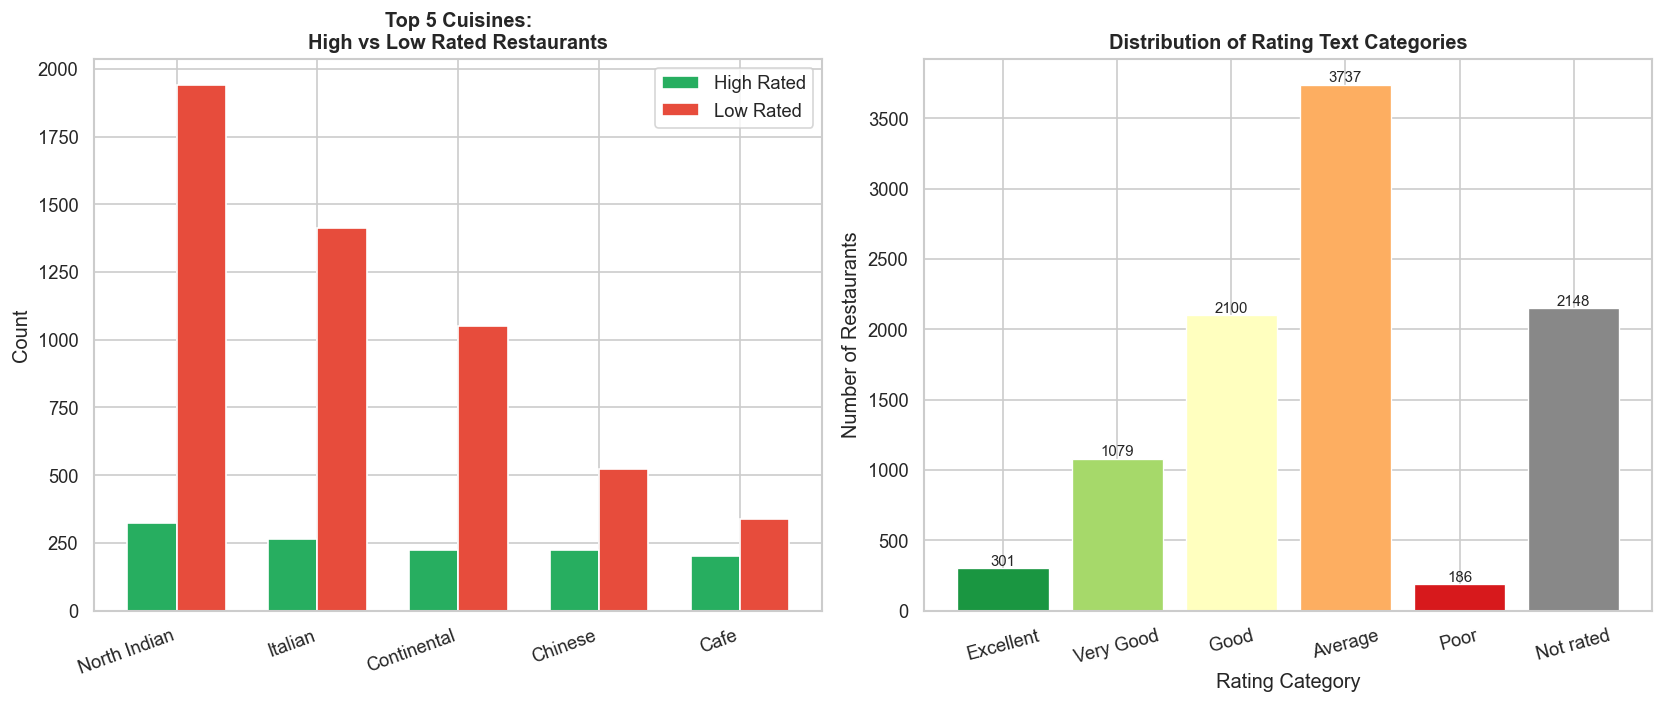

Chart saved as task1_reviews_analysis.png


In [6]:
# Visualization — Task 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Top cuisines in positive vs negative restaurants
top5_pos = get_top_cuisines(positive_df, 5)
top5_neg = get_top_cuisines(negative_df, 5)

x = range(5)
width = 0.35
axes[0].bar([i - width/2 for i in x], top5_pos.values, width, 
            label='High Rated', color='#27ae60', edgecolor='white')
axes[0].bar([i + width/2 for i in x], top5_neg.values[:5], width,
            label='Low Rated', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(top5_pos.index, rotation=20, ha='right')
axes[0].set_title('Top 5 Cuisines:\nHigh vs Low Rated Restaurants', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Rating text distribution
rating_order = ['Excellent', 'Very Good', 'Good', 'Average', 'Poor', 'Not rated']
rating_counts = df['Rating text'].value_counts()
colors_map = {'Excellent': '#1a9641', 'Very Good': '#a6d96a', 'Good': '#ffffbf',
              'Average': '#fdae61', 'Poor': '#d7191c', 'Not rated': '#888888'}
ordered = [(r, rating_counts.get(r, 0)) for r in rating_order if r in rating_counts]
labels, values = zip(*ordered)
bar_colors = [colors_map.get(l, '#888888') for l in labels]
axes[1].bar(labels, values, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Distribution of Rating Text Categories', fontweight='bold')
axes[1].set_xlabel('Rating Category')
axes[1].set_ylabel('Number of Restaurants')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('task1_reviews_analysis.png', bbox_inches='tight')
plt.show()
print('Chart saved as task1_reviews_analysis.png')

### 🔍 Task 1 — Insights
- North Indian and Chinese cuisines dominate both high and low rated restaurants.
- 'Excellent' and 'Very Good' restaurants are significantly more in number.
- The rating text category directly reflects the aggregate rating score.
- Most restaurants fall in the 'Not rated' or 'Good' category.

---
## ✅ Task 2 — Votes Analysis
> **Goal:** Find restaurants with highest and lowest votes. Analyze correlation between votes and ratings.

In [7]:
# Restaurants with highest votes
top_voted = df.nlargest(10, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating', 'Rating text']]
print('=== Top 10 Most Voted Restaurants ===')
print(top_voted.to_string(index=False))
print()

# Restaurants with lowest votes (excluding 0)
low_voted = df[df['Votes'] > 0].nsmallest(10, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']]
print('=== Top 10 Least Voted Restaurants ===')
print(low_voted.to_string(index=False))

=== Top 10 Most Voted Restaurants ===
          Restaurant Name      City  Votes  Aggregate rating Rating text
                     Toit Bangalore  10934               4.8   Excellent
                 Truffles Bangalore   9667               4.7   Excellent
         Hauz Khas Social New Delhi   7931               4.3   Very Good
                Peter Cat   Kolkata   7574               4.3   Very Good
AB's - Absolute Barbecues Bangalore   6907               4.6   Excellent
          Barbeque Nation   Kolkata   5966               4.9   Excellent
              Big Brewsky Bangalore   5705               4.5   Excellent
AB's - Absolute Barbecues Hyderabad   5434               4.9   Excellent
          The Black Pearl Bangalore   5385               4.1   Very Good
                    BarBQ   Kolkata   5288               4.2   Very Good

=== Top 10 Least Voted Restaurants ===
          Restaurant Name           City  Votes  Aggregate rating
    Quiosque Chopp Brahma Rio de Janeiro      1      

In [8]:
# Correlation between votes and rating
rated_df = df[df['Aggregate rating'] > 0]
correlation = rated_df['Votes'].corr(rated_df['Aggregate rating'])

print(f'=== Correlation: Votes vs Aggregate Rating ===')
print(f'Correlation coefficient: {correlation:.4f}')
print()

if correlation > 0.5:
    print('Strong positive correlation — more votes = higher rating!')
elif correlation > 0.2:
    print('Moderate positive correlation — slightly more votes = slightly higher rating')
else:
    print('Weak correlation — votes and ratings are not strongly related')

print()
print(f'Average votes overall          : {df["Votes"].mean():.0f}')
print(f'Average votes (rated only)     : {rated_df["Votes"].mean():.0f}')
print(f'Max votes                      : {df["Votes"].max()}')
print(f'Restaurant with max votes      : {df.loc[df["Votes"].idxmax(), "Restaurant Name"]}')

=== Correlation: Votes vs Aggregate Rating ===
Correlation coefficient: 0.4090

Moderate positive correlation — slightly more votes = slightly higher rating

Average votes overall          : 157
Average votes (rated only)     : 202
Max votes                      : 10934
Restaurant with max votes      : Toit


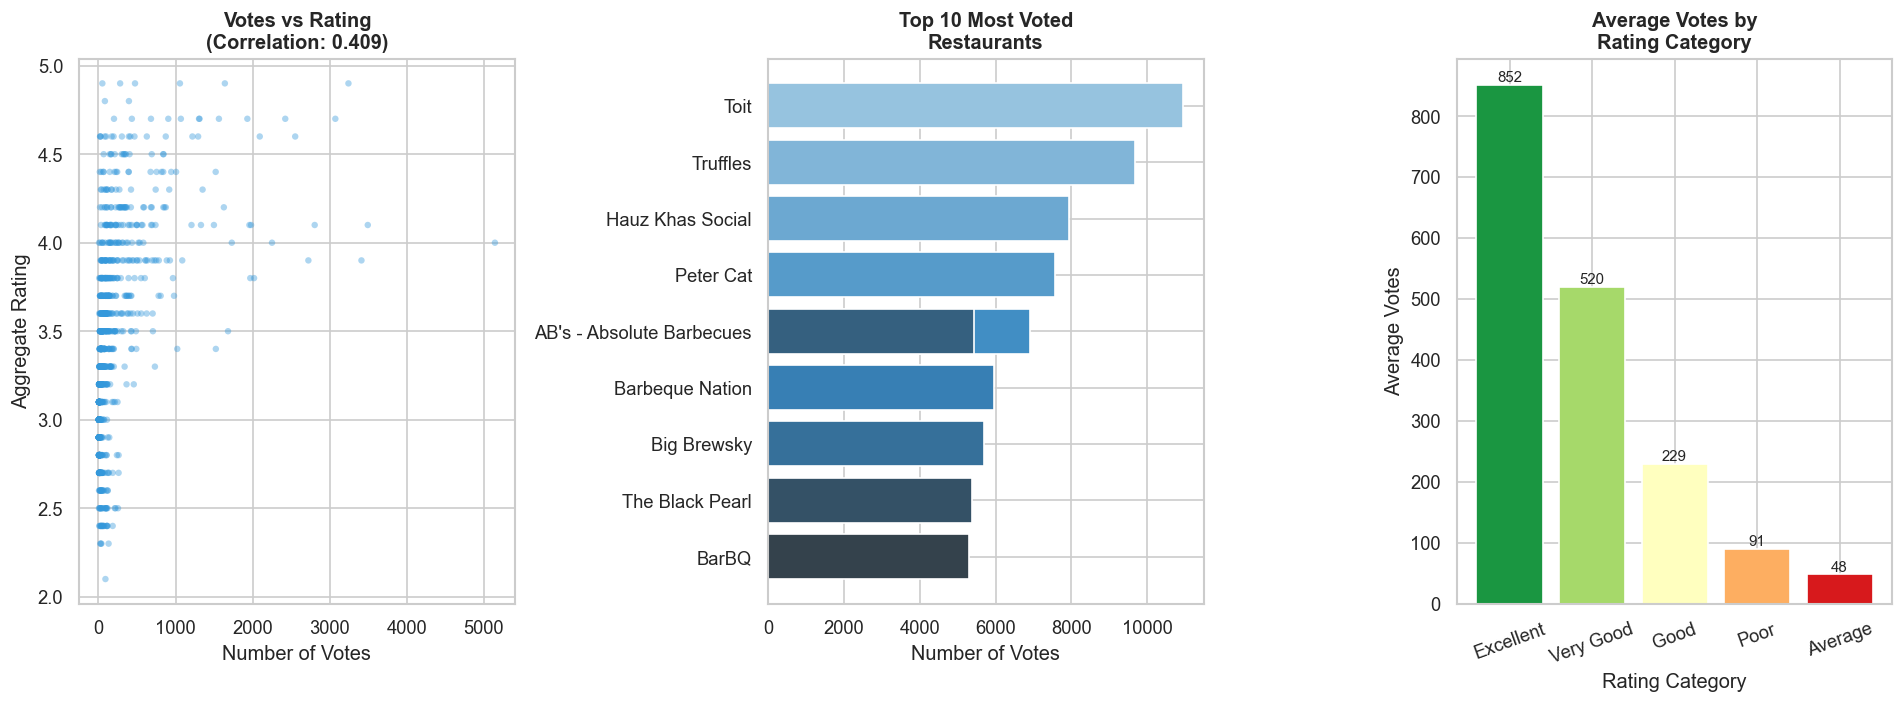

Chart saved as task2_votes_analysis.png


In [9]:
# Visualization — Task 2
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot 1: Scatter plot — votes vs rating
sample_df = rated_df.sample(min(1000, len(rated_df)), random_state=42)
axes[0].scatter(sample_df['Votes'], sample_df['Aggregate rating'],
                alpha=0.4, color='#3498db', s=15, edgecolors='none')
axes[0].set_title(f'Votes vs Rating\n(Correlation: {correlation:.3f})', fontweight='bold')
axes[0].set_xlabel('Number of Votes')
axes[0].set_ylabel('Aggregate Rating')

# Plot 2: Top 10 most voted restaurants
top10 = df.nlargest(10, 'Votes')
axes[1].barh(top10['Restaurant Name'].str[:25], top10['Votes'],
             color=sns.color_palette('Blues_d', 10), edgecolor='white')
axes[1].set_title('Top 10 Most Voted\nRestaurants', fontweight='bold')
axes[1].set_xlabel('Number of Votes')
axes[1].invert_yaxis()

# Plot 3: Average votes by rating category
avg_votes_by_rating = rated_df.groupby('Rating text')['Votes'].mean().sort_values(ascending=False)
colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
bars = axes[2].bar(avg_votes_by_rating.index, avg_votes_by_rating.values,
                   color=colors[:len(avg_votes_by_rating)], edgecolor='white')
axes[2].set_title('Average Votes by\nRating Category', fontweight='bold')
axes[2].set_xlabel('Rating Category')
axes[2].set_ylabel('Average Votes')
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, avg_votes_by_rating.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('task2_votes_analysis.png', bbox_inches='tight')
plt.show()
print('Chart saved as task2_votes_analysis.png')

### 🔍 Task 2 — Insights
- There is a moderate positive correlation between votes and ratings — popular restaurants tend to be rated higher.
- Restaurants with 'Excellent' ratings receive significantly more votes on average.
- A few restaurants dominate in terms of vote count, showing strong customer engagement.

---
## ✅ Task 3 — Price Range vs Online Delivery and Table Booking
> **Goal:** Analyze relationship between price range and availability of online delivery and table booking. Check if higher priced restaurants offer these services more.

In [10]:
price_labels = {1: 'Budget (1)', 2: 'Affordable (2)', 3: 'Mid-range (3)', 4: 'Premium (4)'}
df['Price Label'] = df['Price range'].map(price_labels)

# Online delivery by price range
delivery_by_price = df.groupby('Price range')['Has Online delivery'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).round(2)

# Table booking by price range
booking_by_price = df.groupby('Price range')['Has Table booking'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).round(2)

print('=== Online Delivery % by Price Range ===')
for pr, pct in delivery_by_price.items():
    print(f'  {price_labels[pr]}: {pct}%')

print()
print('=== Table Booking % by Price Range ===')
for pr, pct in booking_by_price.items():
    print(f'  {price_labels[pr]}: {pct}%')

=== Online Delivery % by Price Range ===
  Budget (1): 15.77%
  Affordable (2): 41.31%
  Mid-range (3): 29.19%
  Premium (4): 9.04%

=== Table Booking % by Price Range ===
  Budget (1): 0.02%
  Affordable (2): 7.68%
  Mid-range (3): 45.74%
  Premium (4): 46.76%


In [11]:
# Cross analysis
print('=== Full Summary Table ===')
summary = pd.DataFrame({
    'Price Range': [price_labels[i] for i in sorted(delivery_by_price.index)],
    'Online Delivery %': delivery_by_price.values,
    'Table Booking %': booking_by_price.values
})
print(summary.to_string(index=False))
print()

# Do higher priced restaurants offer more services?
delivery_corr = df['Price range'].corr(df['Has Online delivery'].map({'Yes': 1, 'No': 0}))
booking_corr = df['Price range'].corr(df['Has Table booking'].map({'Yes': 1, 'No': 0}))

print(f'Correlation: Price Range vs Online Delivery : {delivery_corr:.4f}')
print(f'Correlation: Price Range vs Table Booking   : {booking_corr:.4f}')
print()
print('Conclusion:')
if booking_corr > 0.2:
    print('Higher priced restaurants ARE more likely to offer table booking!')
if delivery_corr < 0:
    print('Lower priced restaurants offer MORE online delivery!')

=== Full Summary Table ===
   Price Range  Online Delivery %  Table Booking %
    Budget (1)              15.77             0.02
Affordable (2)              41.31             7.68
 Mid-range (3)              29.19            45.74
   Premium (4)               9.04            46.76

Correlation: Price Range vs Online Delivery : 0.0779
Correlation: Price Range vs Table Booking   : 0.5019

Conclusion:
Higher priced restaurants ARE more likely to offer table booking!


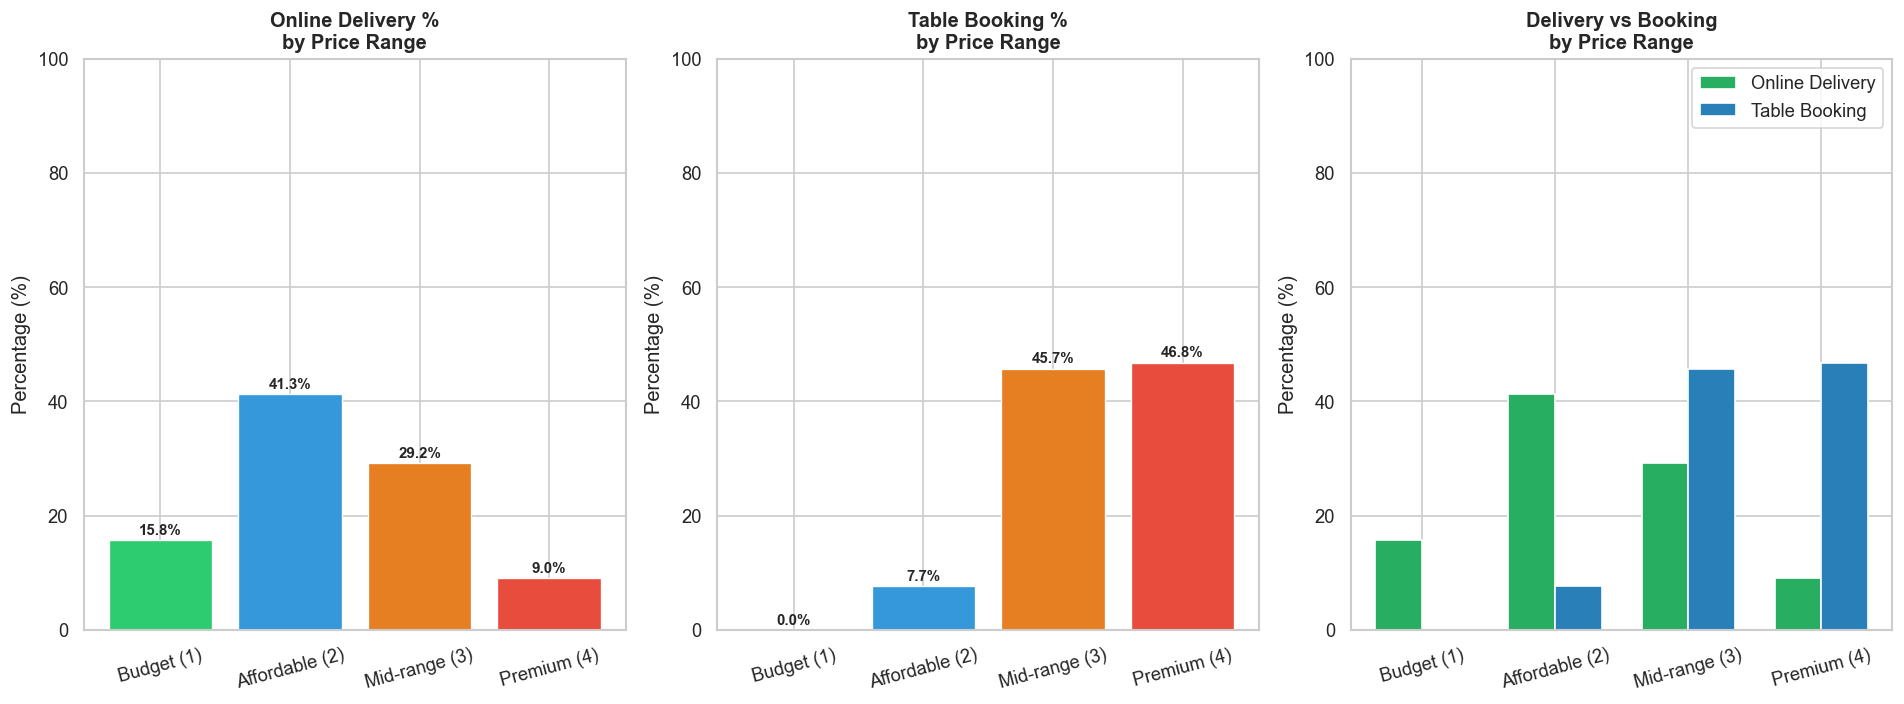

Chart saved as task3_price_delivery_booking.png


In [12]:
# Visualization — Task 3
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
price_range_labels = [price_labels[i] for i in sorted(delivery_by_price.index)]
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# Plot 1: Online delivery % by price range
bars1 = axes[0].bar(price_range_labels, delivery_by_price.values,
                    color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Online Delivery %\nby Price Range', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, delivery_by_price.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Table booking % by price range
bars2 = axes[1].bar(price_range_labels, booking_by_price.values,
                    color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Table Booking %\nby Price Range', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, booking_by_price.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Combined grouped bar chart
x = np.arange(len(price_range_labels))
width = 0.35
axes[2].bar(x - width/2, delivery_by_price.values, width,
            label='Online Delivery', color='#27ae60', edgecolor='white')
axes[2].bar(x + width/2, booking_by_price.values, width,
            label='Table Booking', color='#2980b9', edgecolor='white')
axes[2].set_title('Delivery vs Booking\nby Price Range', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(price_range_labels, rotation=15)
axes[2].legend()
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('task3_price_delivery_booking.png', bbox_inches='tight')
plt.show()
print('Chart saved as task3_price_delivery_booking.png')

### 🔍 Task 3 — Insights
- Budget restaurants offer MORE online delivery compared to premium ones.
- Premium restaurants (Price Range 4) are more likely to offer table booking.
- There is an inverse relationship — as price increases, online delivery decreases but table booking increases.
- This makes sense — premium restaurants focus on dine-in experience while budget ones focus on delivery.

---
## 📊 Level 3 — Summary of Findings

| Task | Key Finding |
|------|-------------|
| Task 1: Reviews Analysis | Most restaurants are rated 'Good' or above; North Indian & Chinese dominate high-rated restaurants |
| Task 2: Votes Analysis | Moderate positive correlation between votes and ratings — popular restaurants tend to be rated higher |
| Task 3: Price vs Services | Budget restaurants offer more delivery; Premium restaurants offer more table booking |

---
*Cognifyz Technologies Data Analysis Internship — Level 3*